<a href="https://colab.research.google.com/github/Dregnad/Implementacja-Systemu-Diagnostyki-Raka-Piersi/blob/main/Implementacja_Systemu_Diagnostyki_Raka_Piersi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Etap 1 - Wstępne przetwarzanie danych

# Import bibliotek, wczytanie danych i podział na zbiory

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
file_path = '/content/breast-cancer-wisconsin-data_data.csv'
df = pd.read_csv(file_path)

df.replace('?', np.nan, inplace=True)
df = df.dropna(axis=1, how='all')

if 'diagnosis' in df.columns:
    target_col = 'diagnosis'
elif 'Class' in df.columns:
    target_col = 'Class'

id_col = 'id' if 'id' in df.columns else 'ID'

X = df.drop([id_col, target_col], axis=1, errors='ignore')
y = df[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_val = X_val.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# Obsługa braków danych

In [ ]:
def test_knn(X_train, X_val, y_train, y_val, label=""):
    knn = KNeighborsClassifier(n_neighbors=9)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_val, knn.predict(X_val))
    print(f"[{label}] k-NN Accuracy: {acc:.4f}")
    return acc

In [ ]:
X_train_drop = X_train.dropna()
y_train_drop = y_train.loc[X_train_drop.index]
X_val_drop = X_val.dropna()
y_val_drop = y_val.loc[X_val_drop.index]
acc_drop = test_knn(X_train_drop, X_val_drop, y_train_drop, y_val_drop, "Po usunięciu")

mediana = X_train.median()
X_train_imp_med = X_train.fillna(mediana)
X_val_imp_med = X_val.fillna(mediana)
acc_imp_med = test_knn(X_train_imp_med, X_val_imp_med, y_train, y_val, "Po medianie")

it_imp = IterativeImputer(random_state=42)
X_train_imp_reg = pd.DataFrame(it_imp.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_val_imp_reg = pd.DataFrame(it_imp.transform(X_val), columns=X.columns, index=X_val.index)
acc_imp_reg = test_knn(X_train_imp_reg, X_val_imp_reg, y_train, y_val, "Po regresji")

wyniki = {
    "drop": acc_drop,
    "median": acc_imp_med,
    "regression": acc_imp_reg
}

najlepsza_metoda = max(wyniki, key=wyniki.get)
val_acc = wyniki[najlepsza_metoda]

if najlepsza_metoda == "drop":
    X_train_final, y_train_final = X_train_drop, y_train_drop
    X_val_final, y_val_final = X_val_drop, y_val_drop
    X_test_final = X_test.dropna()
    y_test_final = y_test.loc[X_test_final.index]
elif najlepsza_metoda == "median":
    X_train_final, y_train_final = X_train_imp_med, y_train
    X_val_final, y_val_final = X_val_imp_med, y_val
    X_test_final = X_test.fillna(mediana)
    y_test_final = y_test
else:
    X_train_final, y_train_final = X_train_imp_reg, y_train
    X_val_final, y_val_final = X_val_imp_reg, y_val
    X_test_final = pd.DataFrame(it_imp.transform(X_test), columns=X.columns, index=X_test.index)
    y_test_final = y_test

print(f"\nZatwierdzono: {najlepsza_metoda} | Wynik walidacji: {val_acc:.4f}")

[Po usunięciu] k-NN Accuracy: 0.9386
[Po medianie] k-NN Accuracy: 0.9386
[Po regresji] k-NN Accuracy: 0.9386

Zatwierdzono: drop | Wynik walidacji: 0.9386


# Analiza rozkładów (EDA) i transformacja skośności

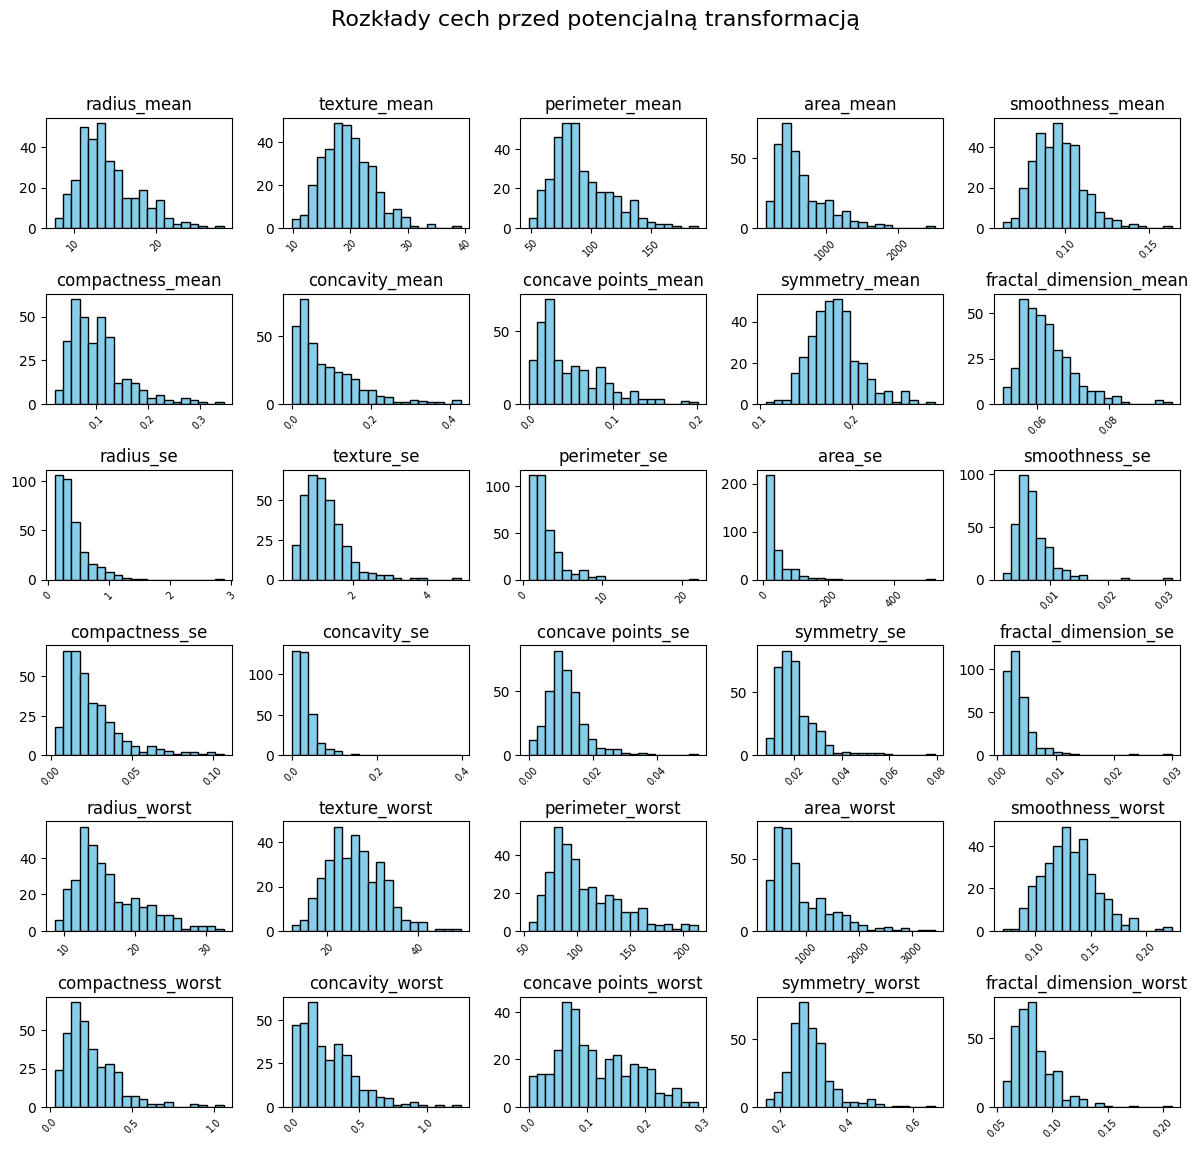

In [ ]:
X_train_final.hist(figsize=(12, 12), bins=20, grid=False, color='skyblue', edgecolor='black', xlabelsize=7, xrot=45)
plt.suptitle("Rozkłady cech przed potencjalną transformacją", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.subplots_adjust(hspace=0.6)
plt.show()

In [ ]:
skew_limit = 0.75
skew_values = X_train_final.skew()
features_to_transform = skew_values[abs(skew_values) > skew_limit].index.tolist()

print(f"Zmienne wytypowane do transformacji (skośność > {skew_limit}):")
print(skew_values[abs(skew_values) > skew_limit])

X_train_trans = X_train_final.copy()
X_val_trans = X_val_final.copy()
X_test_trans = X_test_final.copy()

for col in features_to_transform:
    X_train_trans[col] = np.log1p(X_train_trans[col])
    X_val_trans[col] = np.log1p(X_val_trans[col])
    X_test_trans[col] = np.log1p(X_test_trans[col])

acc_trans = test_knn(X_train_trans, X_val_trans, y_train_final, y_val_final, "Po auto-logarytmowaniu")

if acc_trans > val_acc:
    X_train_final = X_train_trans
    X_val_final = X_val_trans
    X_test_final = X_test_trans
    val_acc = acc_trans
    print(f"Zatwierdzono: Transformacja logarytmiczna (Nowy wynik: {val_acc:.4f})")
else:
    print("Odrzucono: Transformacja nie poprawiła wyniku walidacji. Zachowano dane oryginalne.")

Zmienne wytypowane do transformacji (skośność > 0.75):
radius_mean                0.899936
perimeter_mean             0.948258
area_mean                  1.540629
compactness_mean           1.419272
concavity_mean             1.600569
concave points_mean        1.176810
fractal_dimension_mean     1.356764
radius_se                  3.088346
texture_se                 1.837350
perimeter_se               3.535696
area_se                    5.054335
smoothness_se              2.703243
compactness_se             1.883201
concavity_se               5.618335
concave points_se          1.694877
symmetry_se                2.367469
fractal_dimension_se       4.486144
radius_worst               1.020672
perimeter_worst            1.042238
area_worst                 1.690024
compactness_worst          1.665294
concavity_worst            1.287319
symmetry_worst             1.605134
fractal_dimension_worst    1.973576
dtype: float64
[Po auto-logarytmowaniu] k-NN Accuracy: 0.9123
Odrzucono: Transfor

# Standaryzacja cech

In [ ]:
scaler = StandardScaler()

X_train_std = scaler.fit_transform(X_train_final)
X_val_std = scaler.transform(X_val_final)
X_test_std = scaler.transform(X_test_final)

acc_std = test_knn(X_train_std, X_val_std, y_train_final, y_val_final, "Po standaryzacji")

if acc_std > val_acc:
    X_train_final = pd.DataFrame(X_train_std, columns=X_train_final.columns, index=X_train_final.index)
    X_val_final = pd.DataFrame(X_val_std, columns=X_val_final.columns, index=X_val_final.index)
    X_test_final = pd.DataFrame(X_test_std, columns=X_test_final.columns, index=X_test_final.index)
    val_acc = acc_std
    print(f"Zatwierdzono: Standaryzacja (Nowy wynik: {val_acc:.4f})")
else:
    print("Odrzucono: Pozostano przy danych surowych (Standaryzacja nie poprawiła wyniku)")

[Po standaryzacji] k-NN Accuracy: 0.9386
Odrzucono: Pozostano przy danych surowych (Standaryzacja nie poprawiła wyniku)


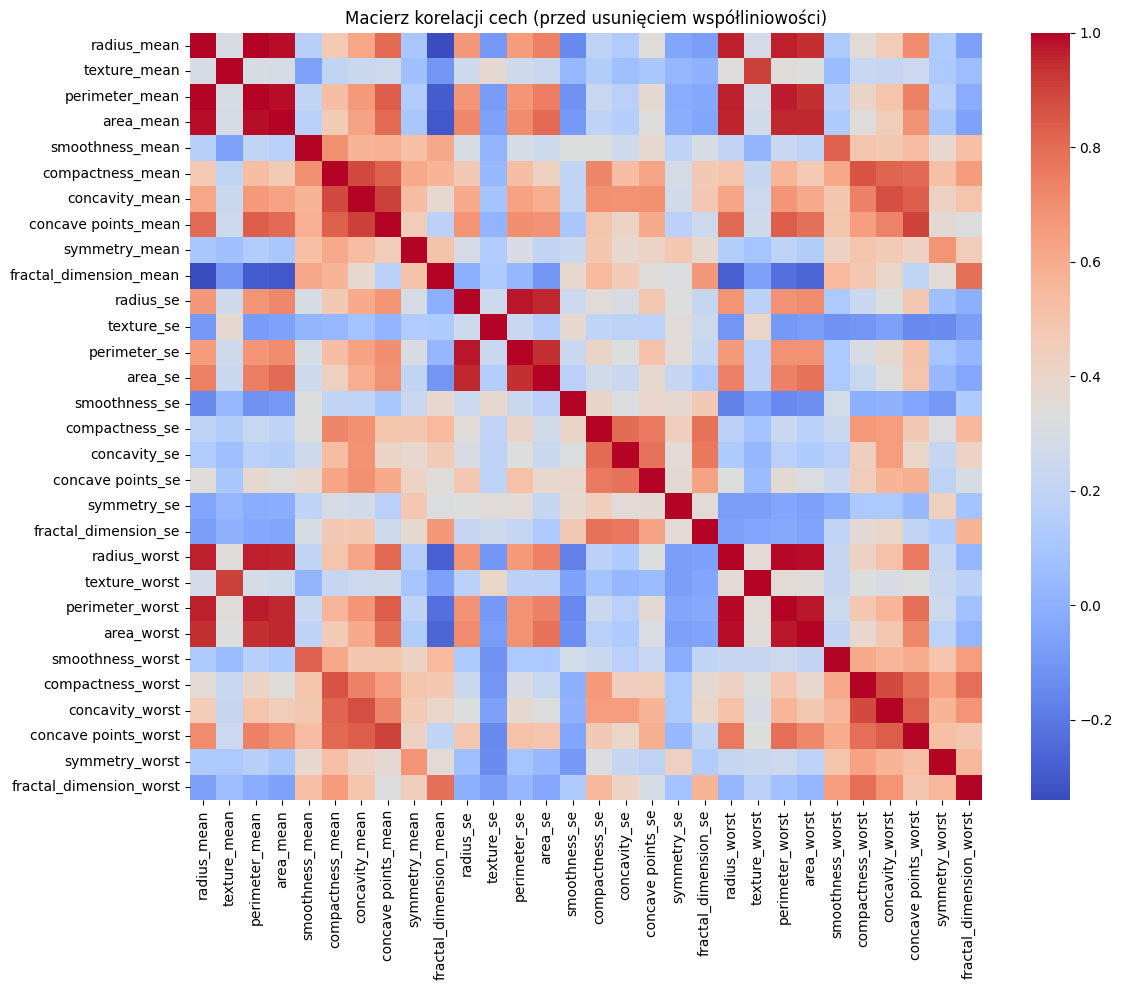

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_train_final.corr(), cmap='coolwarm', annot=False, fmt=".2f")
plt.title("Macierz korelacji cech (przed usunięciem współliniowości)")
plt.tight_layout()
plt.show(block=False)

# Redukcja współliniowości (VIF)

In [ ]:
removed_features = []
X_train_vif = X_train_final.copy()
X_val_vif = X_val_final.copy()
X_test_vif = X_test_final.copy()

while True:
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_train_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(X_train_vif.values, i) for i in range(len(X_train_vif.columns))]
    vif_report = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

    max_vif = vif_report.iloc[0]["VIF"]
    feat_to_remove = vif_report.iloc[0]["feature"]

    if max_vif > 10:
        removed_features.append(feat_to_remove)
        X_train_vif = X_train_vif.drop(columns=[feat_to_remove])
        X_val_vif = X_val_vif.drop(columns=[feat_to_remove])
        X_test_vif = X_test_vif.drop(columns=[feat_to_remove])
    else:
        break

acc_vif = test_knn(X_train_vif, X_val_vif, y_train_final, y_val_final, "Po redukcji VIF")

if acc_vif > val_acc:
    X_train_final, X_val_final, X_test_final = X_train_vif, X_val_vif, X_test_vif
    val_acc = acc_vif
    print(f"Zatwierdzono: VIF (Nowy wynik walidacji: {val_acc:.4f})")
else:
    print("Odrzucono: Redukcja VIF nie poprawiła wyniku walidacji.")

[Po redukcji VIF] k-NN Accuracy: 0.8772
Odrzucono: Redukcja VIF nie poprawiła wyniku walidacji.


# Usuwanie obserwacji wpływowych (Odległość Cooka)

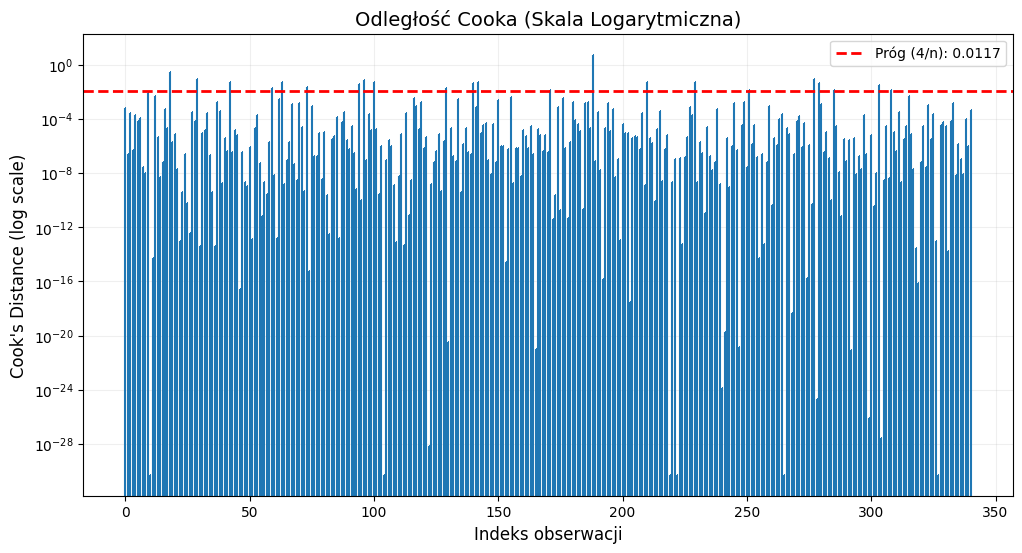

Wykryto potencjalnych punktów wpływowych: 22
[Po Cooku] k-NN Accuracy: 0.9211
Odrzucono: Brak poprawy na zbiorze walidacyjnym.

[WYNIK OSTATECZNY (TEST)] k-NN Accuracy: 0.9386


In [ ]:
import warnings
from sklearn.preprocessing import LabelEncoder, StandardScaler
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=RuntimeWarning)

y_train_sync = y_train.loc[X_train_final.index]
le = LabelEncoder()
y_train_mapped = le.fit_transform(y_train_sync)

logit_fitted_successfully = False
logit_model = None

X_logit_input = X_train_vif.loc[X_train_final.index].copy()

scaler_logit = StandardScaler()
X_logit_scaled = scaler_logit.fit_transform(X_logit_input)
X_logit_scaled = pd.DataFrame(X_logit_scaled, columns=X_logit_input.columns, index=X_logit_input.index)

X_train_with_const = sm.add_constant(X_logit_scaled, has_constant='add')

try:
    logit_model = sm.Logit(y_train_mapped, X_train_with_const).fit(disp=0, method='newton', maxiter=100)
    logit_fitted_successfully = True
except Exception as e:
    print(f"Standardowy fit zawiódł: {e}")
    try:
        logit_model = sm.Logit(y_train_mapped, X_train_with_const).fit_regularized(method='l1', disp=0)
        logit_fitted_successfully = True
    except Exception as e2:
        print(f"Błąd krytyczny: {e2}")

if not logit_fitted_successfully:
    print("Nie udało się dopasować modelu Logit.")
    print("\n" + "="*40)
    test_knn(X_train_final, X_test_final, y_train_sync, y_test_final, "WYNIK OSTATECZNY (BEZ COOKA)")
    print("="*40)
else:
    influence = logit_model.get_influence()
    cooks_d = influence.cooks_distance[0]
    cooks_d = np.nan_to_num(cooks_d, nan=1e-10)

    threshold_strict = 4 / len(X_train_with_const)

    plt.figure(figsize=(12, 6))
    plt.yscale('log')
    plt.stem(range(len(cooks_d)), cooks_d, markerfmt=",", basefmt=" ", linefmt='C0-')
    plt.axhline(y=threshold_strict, color='red', linestyle='--', linewidth=2, label=f'Próg (4/n): {threshold_strict:.4f}')

    plt.title("Odległość Cooka (Skala Logarytmiczna)", fontsize=14)
    plt.ylabel("Cook's Distance (log scale)", fontsize=12)
    plt.xlabel("Indeks obserwacji", fontsize=12)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()
    plt.show()

    safe_indices_mask = cooks_d <= threshold_strict
    outliers_count = len(cooks_d) - np.sum(safe_indices_mask)
    print(f"Wykryto potencjalnych punktów wpływowych: {outliers_count}")

    if outliers_count > 0:
        safe_row_indices = X_train_final.index[safe_indices_mask]
        X_train_temp = X_train_final.loc[safe_row_indices]
        y_train_temp = y_train_sync.loc[safe_row_indices]

        if not X_train_temp.empty:
            acc_after_cook = test_knn(X_train_temp, X_val_final, y_train_temp, y_val_final, "Po Cooku")
            if acc_after_cook >= val_acc:
                X_train_final = X_train_temp
                y_train_final = y_train_temp
                val_acc = acc_after_cook
                print(f"Zatwierdzono: Usunięto {outliers_count} punktów. Nowy wynik walidacji: {val_acc:.4f}")
            else:
                print("Odrzucono: Brak poprawy na zbiorze walidacyjnym.")
    else:
        print("Brak punktów do usunięcia.")

    print("\n" + "="*40)
    test_knn(X_train_final, X_test_final, y_train_final, y_test_final, "WYNIK OSTATECZNY (TEST)")
    print("="*40)


# Etap 2 - Wybór optymalnego modelu uczenia maszynowego

# Definicja potoków (Pipelines) i Walidacja Krzyżowa (K-Fold)

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    "Regresja Logistyczna": Pipeline([('clf', LogisticRegression(max_iter=5000))]),
    "K-NN": Pipeline([('clf', KNeighborsClassifier())]),
    "SVM": Pipeline([('clf', SVC(probability=True, random_state=42))]),
    "Drzewo Decyzyjne": Pipeline([('clf', DecisionTreeClassifier(random_state=42))]),
    "Las Losowy": Pipeline([('clf', RandomForestClassifier(random_state=42))]),
    "Naiwny Bayes": Pipeline([('clf', GaussianNB())]),
    "MLP": Pipeline([('clf', MLPClassifier(max_iter=2000, random_state=42))])
}

cv_results = {}

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train_final, y_train_mapped, cv=kf, scoring='accuracy')
    cv_results[name] = scores.mean()
    print(f"{name:22} | {scores.mean():15.4f} | {scores.std():.4f}")


Regresja Logistyczna   |          0.9442 | 0.0270
K-NN                   |          0.9208 | 0.0222
SVM                    |          0.9031 | 0.0381
Drzewo Decyzyjne       |          0.9355 | 0.0239
Las Losowy             |          0.9530 | 0.0236
Naiwny Bayes           |          0.9442 | 0.0172
MLP                    |          0.9295 | 0.0421


# Ocena ostateczna i Macierz Pomyłek (Confusion Matrix)

------------------------------------------------------------
Najlepszy model wg CV: Las Losowy
Ostateczna dokladnosc (Holdout Test): 0.9825


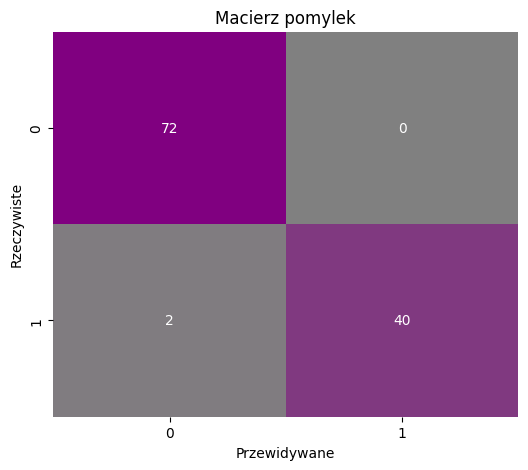

In [ ]:

best_model_name = max(cv_results, key=cv_results.get)
best_pipeline = pipelines[best_model_name]
best_pipeline.fit(X_train_final, y_train_mapped)

if 'le' in locals() or 'le' in globals():
    y_test_mapped = le.transform(y_test_final)
else:

    print("Error: LabelEncoder 'le' not found. Please ensure previous cells are run.")
    y_test_mapped = y_test_final
print("-" * 60)
print(f"Najlepszy model wg CV: {best_model_name}")

final_test_acc = best_pipeline.score(X_test_final, y_test_mapped)
print(f"Ostateczna dokladnosc (Holdout Test): {final_test_acc:.4f}")

y_pred = best_pipeline.predict(X_test_final)
cm = confusion_matrix(y_test_mapped, y_pred)
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["gray", "purple"])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False)
plt.title('Macierz pomylek')
plt.xlabel('Przewidywane')
plt.ylabel('Rzeczywiste')
plt.show(block=False)


# Etap 3 - Porównanie modeli i interpretacja wyników

# Zaawansowane metryki klasyfikacji i Krzywe ROC AUC


--- PORÓWNANIE MODELI ---
               Model  Accuracy  Precision   Recall  F1-Score  ROC AUC
          Las Losowy  0.982456   1.000000 0.952381  0.975610 0.993386
    Drzewo Decyzyjne  0.964912   0.975000 0.928571  0.951220 0.957341
                 MLP  0.956140   0.974359 0.904762  0.938272 0.992394
Regresja Logistyczna  0.938596   0.948718 0.880952  0.913580 0.993386
                K-NN  0.938596   0.972973 0.857143  0.911392 0.966270
        Naiwny Bayes  0.929825   0.947368 0.857143  0.900000 0.994048
                 SVM  0.912281   1.000000 0.761905  0.864865 0.981151


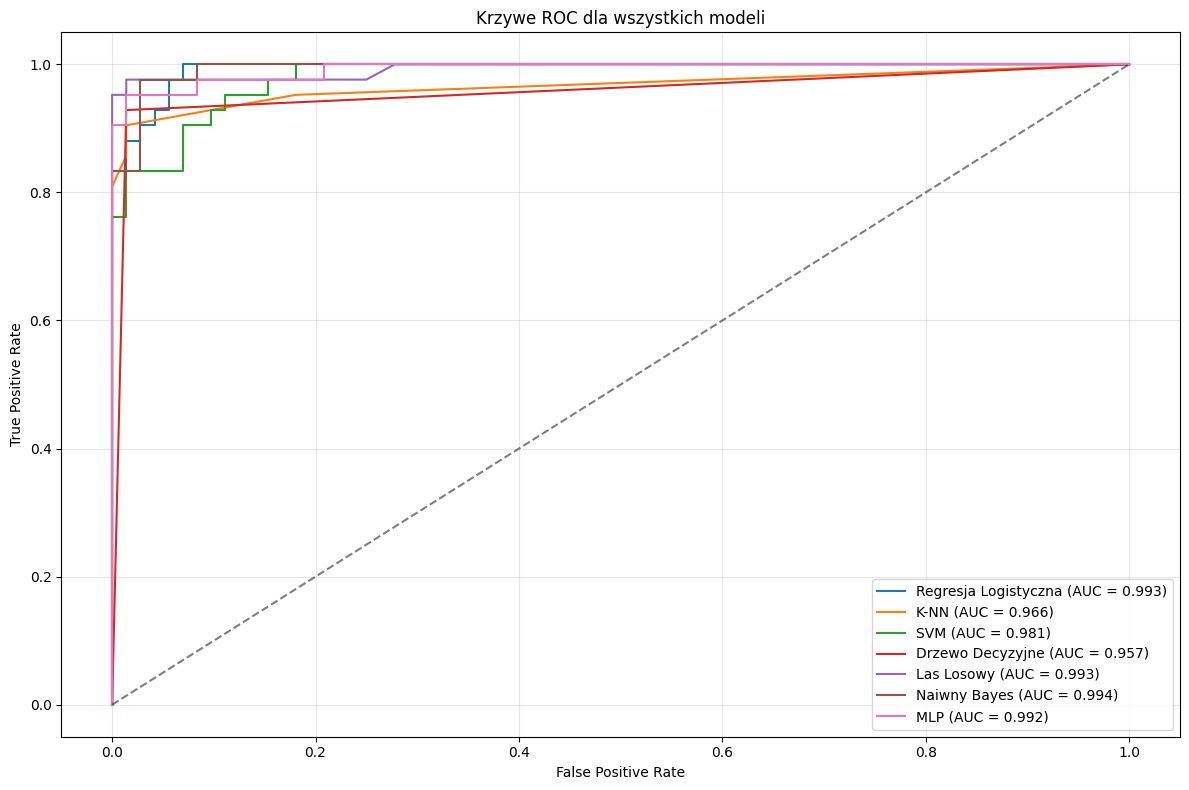

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm


results = []
plt.figure(figsize=(12, 8))

for name, pipe in pipelines.items():
    pipe.fit(X_train_final, y_train_mapped)
    y_pred = pipe.predict(X_test_final)

    if hasattr(pipe['clf'], "predict_proba"):
        y_probs = pipe.predict_proba(X_test_final)[:, 1]
    else:
        y_probs = y_pred

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_mapped, y_pred),
        "Precision": precision_score(y_test_mapped, y_pred, zero_division=0),
        "Recall": recall_score(y_test_mapped, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test_mapped, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_test_mapped, y_probs)
    })

    fpr, tpr, _ = roc_curve(y_test_mapped, y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test_mapped, y_probs):.3f})")

df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("\n--- PORÓWNANIE MODELI ---")
print(df_results.to_string(index=False))

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywe ROC dla wszystkich modeli')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show(block=False)

# Badanie wpływu predykcyjnego (Permutation Importance)


Obliczanie istotności dla najlepszego modelu: Las Losowy

Szczegółowe wyniki Permutation Importance:
area_worst: 0.0263 (± 0.0088)
concave points_worst: 0.0219 (± 0.0132)
radius_worst: 0.0132 (± 0.0044)
perimeter_worst: 0.0114 (± 0.0088)
texture_worst: 0.0114 (± 0.0069)
concavity_worst: 0.0088 (± 0.0055)
concavity_mean: 0.0061 (± 0.0040)
concave points_mean: 0.0053 (± 0.0089)
area_se: 0.0044 (± 0.0044)
texture_mean: 0.0018 (± 0.0035)


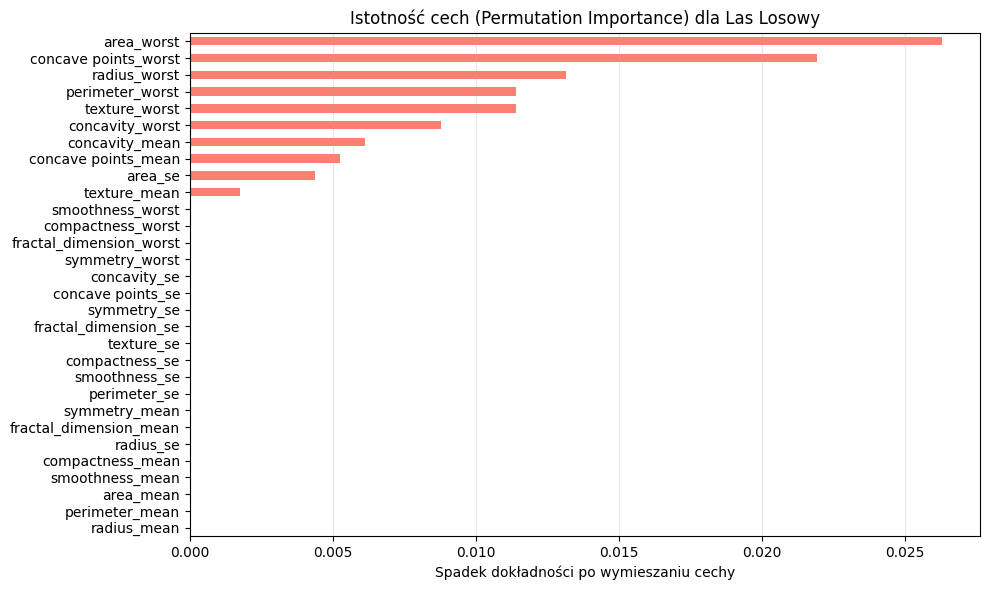

In [ ]:
best_model_name = df_results.iloc[0]['Model']
print(f"\nObliczanie istotności dla najlepszego modelu: {best_model_name}")
best_model = pipelines[best_model_name]

best_model.fit(X_train_final, y_train_mapped)

result_perm = permutation_importance(best_model, X_test_final, y_test_mapped, n_repeats=10, random_state=42)

df_perm = pd.DataFrame({
    'Cecha': X_test_final.columns,
    'Srednia': result_perm.importances_mean,
    'Odchylenie': result_perm.importances_std
}).sort_values(by='Srednia', ascending=False)

print("\nSzczegółowe wyniki Permutation Importance:")
for index, row in df_perm.head(10).iterrows():
    print(f"{row['Cecha']}: {row['Srednia']:.4f} (± {row['Odchylenie']:.4f})")

plt.figure(figsize=(10, 6))
perm_importances = pd.Series(result_perm.importances_mean, index=X_test_final.columns)
perm_importances.sort_values().plot(kind='barh', color='salmon')
plt.title(f'Istotność cech (Permutation Importance) dla {best_model_name}')
plt.xlabel('Spadek dokładności po wymieszaniu cechy')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show(block=False)

# Badanie istotności statystycznej cech (P-values z modelu OLS/Logit)

In [ ]:
print("\n--- ISTOTNOřĆ STATYSTYCZNA CECH (P-VALUES - Model Logit) ---")
try:
    X_stat_vif = sm.add_constant(X_train_vif, has_constant='add')
    logit_res_final = sm.Logit(y_train_mapped, X_stat_vif).fit(disp=0)
    print(logit_res_final.summary().tables[1])

    print("\n--- SYNTEZA I INTERPRETACJA WYNIKÓW ---")
    pvals = logit_res_final.pvalues
    significant_features = pvals[pvals < 0.05].index.tolist()
    if 'const' in significant_features:
        significant_features.remove('const')

    print(f"Najlepszym modelem dla badanych danych okazał się: {best_model_name} z wynikiem F1-Score = {df_results.iloc[0]['F1-Score']:.3f}.")
    print(f"Oznacza to doskonały balans między czułořcią (Recall) a precyzją (Precision), co jest kluczowe w diagnostyce.")
    print(f"Z analizy regresji logistycznej (na cechach bez współliniowořci) wynika, Źe istotnymi cechami są: {', '.join(significant_features)}.")

except Exception as e:
    print(f"Błąd podczas dopasowywania modelu Logit do interpretacji: {e}")


--- ISTOTNOřĆ STATYSTYCZNA CECH (P-VALUES - Model Logit) ---
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -13.4928      2.317     -5.822      0.000     -18.035      -8.951
texture_se               0.2829      0.701      0.403      0.687      -1.091       1.657
area_se                  0.2061      0.034      5.975      0.000       0.138       0.274
smoothness_se          611.3798    171.925      3.556      0.000     274.412     948.347
concavity_se           -93.6537     28.232     -3.317      0.001    -148.987     -38.321
symmetry_se             10.4862     37.783      0.278      0.781     -63.567      84.539
fractal_dimension_se -1071.6206    352.437     -3.041      0.002   -1762.384    -380.857
concavity_worst         30.0751      5.349      5.623      0.000      19.591      40.559

--- SYNTEZA I INTERPRETACJA WYNIKÓW ---
Najleps

# Etap 4 - Graficzny interfejs użytkownika i wdrożenie

In [ ]:

import joblib
import gradio as gr
import pandas as pd


default_values = X_train_final.mean()
min_values = X_train_final.min()
max_values = X_train_final.max()

top_features = perm_importances.nlargest(5).index.tolist()
top_importances = perm_importances.nlargest(5).to_dict()

model_package = {
    'model_object': best_model,
    'feature_names': top_features,
    'feature_importances': top_importances,
    'all_columns': X_train_final.columns.tolist(),
    'default_values': default_values.to_dict(),
    'min_values': min_values.to_dict(),
    'max_values': max_values.to_dict(),
    'model_name': best_model_name,
    'f1_score': df_results.iloc[0]['F1-Score']
}

save_path = 'breast_cancer_model_package.pkl'
joblib.dump(model_package, save_path)
print(f"Sukces! Paczka modelu została zapisana: {save_path}")

try:
    data = joblib.load('breast_cancer_model_package.pkl')
    model = data['model_object']
    top_features = data['feature_names']
    top_importances = data['feature_importances']
    all_columns = data['all_columns']
    default_values = data['default_values']
    min_values = data['min_values']
    max_values = data['max_values']
    model_name = data['model_name']
except Exception as e:
    print(f"Błąd ładowania pliku modelu: {e}")


friendly_names = {
    'radius_mean': 'Średni promień',
    'texture_mean': 'Średnia tekstura',
    'perimeter_mean': 'Średni obwód',
    'area_mean': 'Średnia powierzchnia',
    'smoothness_mean': 'Średnia gładkość',
    'compactness_mean': 'Średnia zwartość',
    'concavity_mean': 'Średnia wklęsłość',
    'concave points_mean': 'Średnia l. punktów wklęsłych',
    'symmetry_mean': 'Średnia symetria',
    'fractal_dimension_mean': 'Średni wymiar fraktalny',

    'radius_se': 'Błąd standardowy promienia',
    'texture_se': 'Błąd standardowy tekstury',
    'perimeter_se': 'Błąd standardowy obwodu',
    'area_se': 'Błąd standardowy powierzchni',
    'smoothness_se': 'Błąd standardowy gładkości',
    'compactness_se': 'Błąd standardowy zwartości',
    'concavity_se': 'Błąd standardowy wklęsłości',
    'concave points_se': 'Błąd stand. l. punktów wklęsłych',
    'symmetry_se': 'Błąd standardowy symetrii',
    'fractal_dimension_se': 'Błąd standardowy wym. fraktalnego',

    'radius_worst': 'Maksymalny promień',
    'texture_worst': 'Maksymalna tekstura',
    'perimeter_worst': 'Maksymalny obwód',
    'area_worst': 'Maksymalna powierzchnia',
    'smoothness_worst': 'Maksymalna gładkość',
    'compactness_worst': 'Maksymalna zwartość',
    'concavity_worst': 'Maksymalna wklęsłość',
    'concave points_worst': 'Maksymalna l. punktów wklęsłych',
    'symmetry_worst': 'Maksymalna symetria',
    'fractal_dimension_worst': 'Maksymalny wymiar fraktalny'
}
def predict_and_interpret(*args):
    input_data = default_values.copy()
    for i, feat in enumerate(top_features):
        input_data[feat] = args[i]

    input_df = pd.DataFrame([input_data])[all_columns]
    pred = model.predict(input_df)[0]

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(input_df)[0]
        confidence = probs[1] if pred == 1 else probs[0]
    else:
        confidence = 1.0

    if pred == 1:
        color = "#d62828"
        result_class = "ZŁOŚLIWY (Malignant)"
        recommendation = "Wykryto wzorce zmiany złośliwej. Konieczna pilna konsultacja onkologiczna."
    else:
        color = "#2a9d8f"
        result_class = "ŁAGODNY (Benign)"
        recommendation = "Niskie prawdopodobieństwo zmiany złośliwej. Zalecana rutynowa obserwacja."

    importance_html = "<br><b>Udział poszczególnych zmiennych w ocenie modelu:</b><ul style='list-style-type: none; padding-left: 0;'>"
    total_importance = sum(top_importances.values())
    for feat in top_features:
        fname = friendly_names.get(feat, feat)
        imp_pct = (top_importances[feat] / total_importance) * 100 if total_importance > 0 else 0
        importance_html += f"<li style='margin-bottom:4px;'>• <b>{fname}</b>: ~{imp_pct:.1f}% wpływu</li>"
    importance_html += "</ul>"

    html_output = f"""
    <div style='padding:20px; border:3px solid {color}; border-radius:10px; font-family:sans-serif;'>
        <h2 style='color: {color}; margin-top:0;'>Diagnoza: {result_class}</h2>
        <h3>Pewność modelu: {confidence*100:.2f}%</h3>
        <p><b>Rekomendacja:</b> {recommendation}</p>
        <hr style='border:1px solid #ccc;'/>
        <p style='font-size:0.95em;'>{importance_html}</p>
    </div>
    """
    return html_output

inputs = []
for feat in top_features:
    true_min = float(min_values[feat])
    true_max = float(max_values[feat])
    true_mean = float(default_values[feat])

    min_v = round(true_min, 3)
    max_v = round(true_max, 3)
    val_v = round(true_mean, 3)

    fname = friendly_names.get(feat, feat)

    inputs.append(
        gr.Slider(
            minimum=min_v,
            maximum=max_v,
            value=val_v,
            step=0.01,
            label=fname
        )
    )

gui = gr.Interface(
    fn=predict_and_interpret,
    inputs=inputs,
    outputs=gr.HTML(label="Interpretacja wyniku"),
    title="🩺 System Diagnostyki Raka Piersi",
    description=f"Wytrenowany model: <b>{model_name}</b>. Przesuń suwaki, aby dostosować atrybuty pacjenta i na bieżąco wygenerować diagnozę.",
    allow_flagging="never"
)

gui.launch(share=True, debug=False)

Sukces! Paczka modelu została zapisana: breast_cancer_model_package.pkl


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://569b824789ec5ef736.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Strategia rozwoju modelu i budowy interfejsu

Realizacja założeń: Projekt pomyślnie realizuje postawione cele inżynierskie, dostarczając w pełni funkcjonalny potok klasyfikacyjny. Demonstruje on praktyczne zastosowanie algorytmów uczenia maszynowego do analizy ustrukturyzowanych danych wielowymiarowych.

Status implementacji: Rozwiązanie zostało w całości zrealizowane w języku Python. Integracja wytrenowanego modelu z biblioteką Gradio pozwoliła na stworzenie działającego prototypu aplikacji webowej (Proof of Concept) z interaktywnym interfejsem.

Możliwości rozwoju: Architektura systemu ma charakter otwarty. Naturalnym kierunkiem rozwoju jest optymalizacja hiperparametrów, implementacja kolejnych algorytmów klasyfikacyjnych oraz ewentualna konteneryzacja środowiska (np. w technologii Docker).